# GMMainPlot：LISA noise model 之前的纯 Python 绘图

本 notebook 整理自 `Mathematica/v2/GMMainPlot_v2.0.nb` 中 **LISA noise model** 之前的内容。计算仅依赖 `src/gmlib.py` 和可选的 `data/*.npz` 缓存，不依赖 Mathematica notebook 或 `.m` 文件。缓存缺失时会自动执行纯 Python 数值积分并写回 `data`。

In [66]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

%matplotlib inline

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src' / 'gmlib.py').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from gmlib import (
    DataRepository, GMModel, GMParameters, IntegrationSettings,
    PLANCK_TIME_S, luminosity_distance_planck, plot_growth_eigensystem,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'legend.frameon': False,
})
PROJECT_ROOT

PosixPath('/global/u1/l/liuyh15/WorkSpace/GM')

## 1. 参数与模型

下一个 cell 集中放置 Mathematica notebook 使用的物理参数和绘图控制参数。`q` 决定积分表缓存文件；`m1`、`alpha` 和 `mc` 在加载积分表后进入物理量计算。

In [67]:
# ===== User parameters: edit this cell =====
q = 0.5                # mass ratio m2 / m1
m1 = 100.0               # primary black-hole mass [solar masses]
alpha = 0.06             # gravitational fine-structure constant
mc = 0.01                 # cloud mass / m1

number = 200             # separation samples
x_start = 10.0           # R / r_b1
x_end = 38.0
evolution_samples = 2_000
strain_state = 0         # zero-based eigenstate index
redshift = 0.5

In [68]:
repository = DataRepository.from_project_root(PROJECT_ROOT)
parameters = GMParameters(
    mass_ratio=q,
    primary_mass_solar=m1,
    alpha=alpha,
    cloud_mass_fraction=mc,
)
cache_path = repository.model_cache_path(
    mass_ratio=q, number=number, start=x_start, end=x_end
)
model = GMModel.from_repository(
    repository,
    parameters,
    number=number,
    start=x_start,
    end=x_end,
    integration_settings=IntegrationSettings(workers=-1),
)
x = model.separation
scale = parameters.energy_scale
state_labels = [rf'$\hat{{\eta}}_{index}$' for index in range(1, 7)]
basis_labels = [
    r'$|200,1\rangle$', r'$|21{-}1,1\rangle$', r'$|211,1\rangle$',
    r'$|200,2\rangle$', r'$|21{-}1,2\rangle$', r'$|211,2\rangle$',
]

print(f'cache: {cache_path} (exists={cache_path.exists()})')
model.validation_metrics()

cache: /global/u1/l/liuyh15/WorkSpace/GM/data/gm_tables_v1_q0.5_n200_x10_38.npz (exists=True)


{'separation_shape': (200,),
 'hamiltonian_shape': (200, 6, 6),
 'cloud_center_shape': (200, 6),
 'cloud_quadrupole_shape': (200, 6, 3, 3),
 'hamiltonian_hermiticity_max_abs': 0.0,
 'omega_lz_hermiticity_max_abs': 0.0,
 'eigen_residual_max_abs': 9.434555225481514e-16,
 'gw_frequency_squared_min': 1.5568348712902573e-93,
 'gr_power_min': 1.881699553950111e-20}

In [69]:
def plot_state_curves(ax, values, ylabel, *, yscale='linear'):
    values = np.asarray(values)
    if values.shape != (x.size, 6):
        raise ValueError(f'expected {(x.size, 6)}, received {values.shape}')
    for state, label in enumerate(state_labels):
        ax.plot(x, values[:, state], label=label)
    ax.set(xlabel=r'$R/r_{b,1}$', ylabel=ylabel, yscale=yscale)
    ax.legend(fontsize=8, ncol=2)
    return ax


def align_eigenvector_signs(vectors):
    # Remove arbitrary point-to-point signs without changing components.
    aligned = np.real_if_close(vectors, tol=1_000).real.copy()
    for state in range(aligned.shape[1]):
        for point in range(1, aligned.shape[0]):
            if np.dot(aligned[point - 1, state], aligned[point, state]) < 0.0:
                aligned[point, state] *= -1.0
    return aligned


def isolated_binary_frequency_squared(model):
    p = model.parameters
    radius = model.separation * p.bohr_radius_primary
    return (
        (p.primary_mass + p.secondary_mass + p.cloud_mass)
        / (np.pi**2 * radius**3)
    )


def isolated_binary_power(model):
    p = model.parameters
    radius = model.separation * p.bohr_radius_primary
    total_mass = p.primary_mass + p.secondary_mass + p.cloud_mass
    cloud_on_primary = (
        (32.0 / 5.0)
        * (p.primary_mass + p.cloud_mass) ** 2
        * p.secondary_mass**2
        * total_mass
        / radius**5
    )
    cloud_on_secondary = (
        (32.0 / 5.0)
        * p.primary_mass**2
        * (p.secondary_mass + p.cloud_mass) ** 2
        * total_mass
        / radius**5
    )
    result = np.empty((model.separation.size, 6), dtype=np.float64)
    result[:, :3] = cloud_on_primary[:, None]
    result[:, 3:] = cloud_on_secondary[:, None]
    return result

## 2. 本征矢、本征能量与导数

Mathematica 原代码用符号阈值修补本征矢曲线。这里用相邻本征矢重叠来统一整体符号，因此不会单独翻转某个分量。

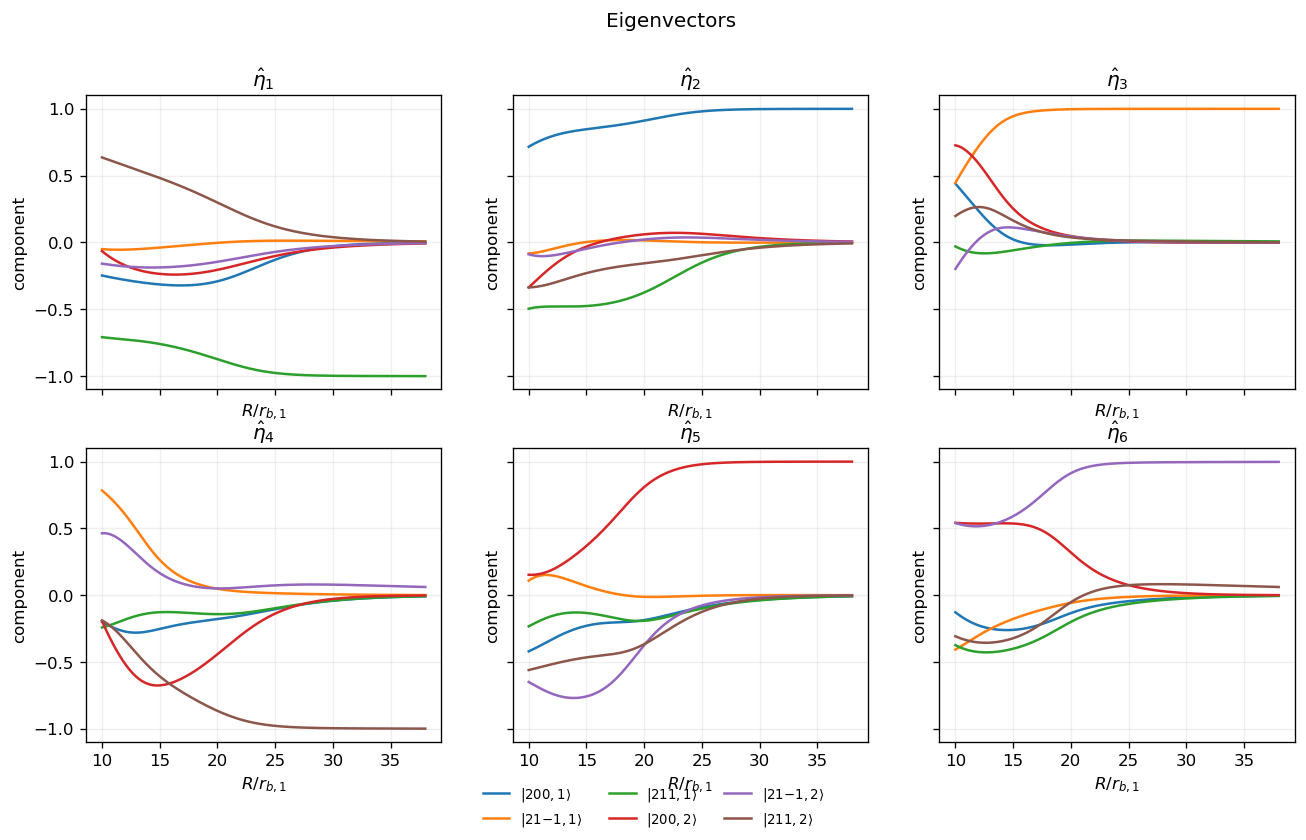

In [70]:
aligned_vectors = align_eigenvector_signs(model.eigenvectors)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for state, ax in enumerate(axes.flat):
    for component, label in enumerate(basis_labels):
        ax.plot(x, aligned_vectors[:, state, component], label=label)
    ax.set_title(state_labels[state])
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(r'$R/r_{b,1}$')
    ax.set_ylabel('component')
handles, labels = axes.flat[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=8)
fig.suptitle('Eigenvectors')
plt.show()

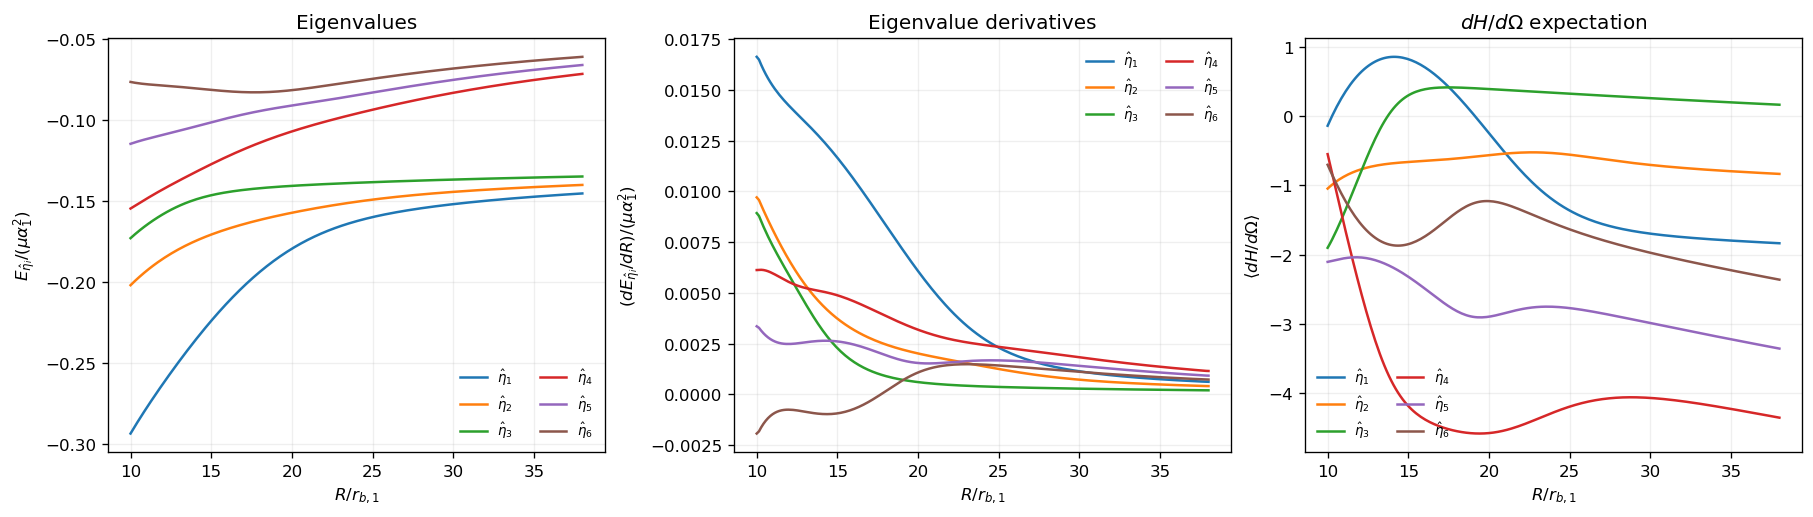

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_state_curves(
    axes[0], model.eigenvalues / scale,
    r'$E_{\hat{\eta}_i}/(\mu\alpha_1^2)$',
)
plot_state_curves(
    axes[1], model.eigenvalue_derivatives / scale,
    r'$(dE_{\hat{\eta}_i}/dR)/(\mu\alpha_1^2)$',
)
plot_state_curves(
    axes[2], model.dh_domega_expectation,
    r'$\langle dH/d\Omega\rangle$',
)
axes[0].set_title('Eigenvalues')
axes[1].set_title('Eigenvalue derivatives')
axes[2].set_title(r'$dH/d\Omega$ expectation')
plt.show()

## 3. 云质心与 GW 频率

`omega0` 是把云质量视为附着在黑洞上的孤立双星参考频率。下方同时给出频率平方和频率本身的相对偏差。

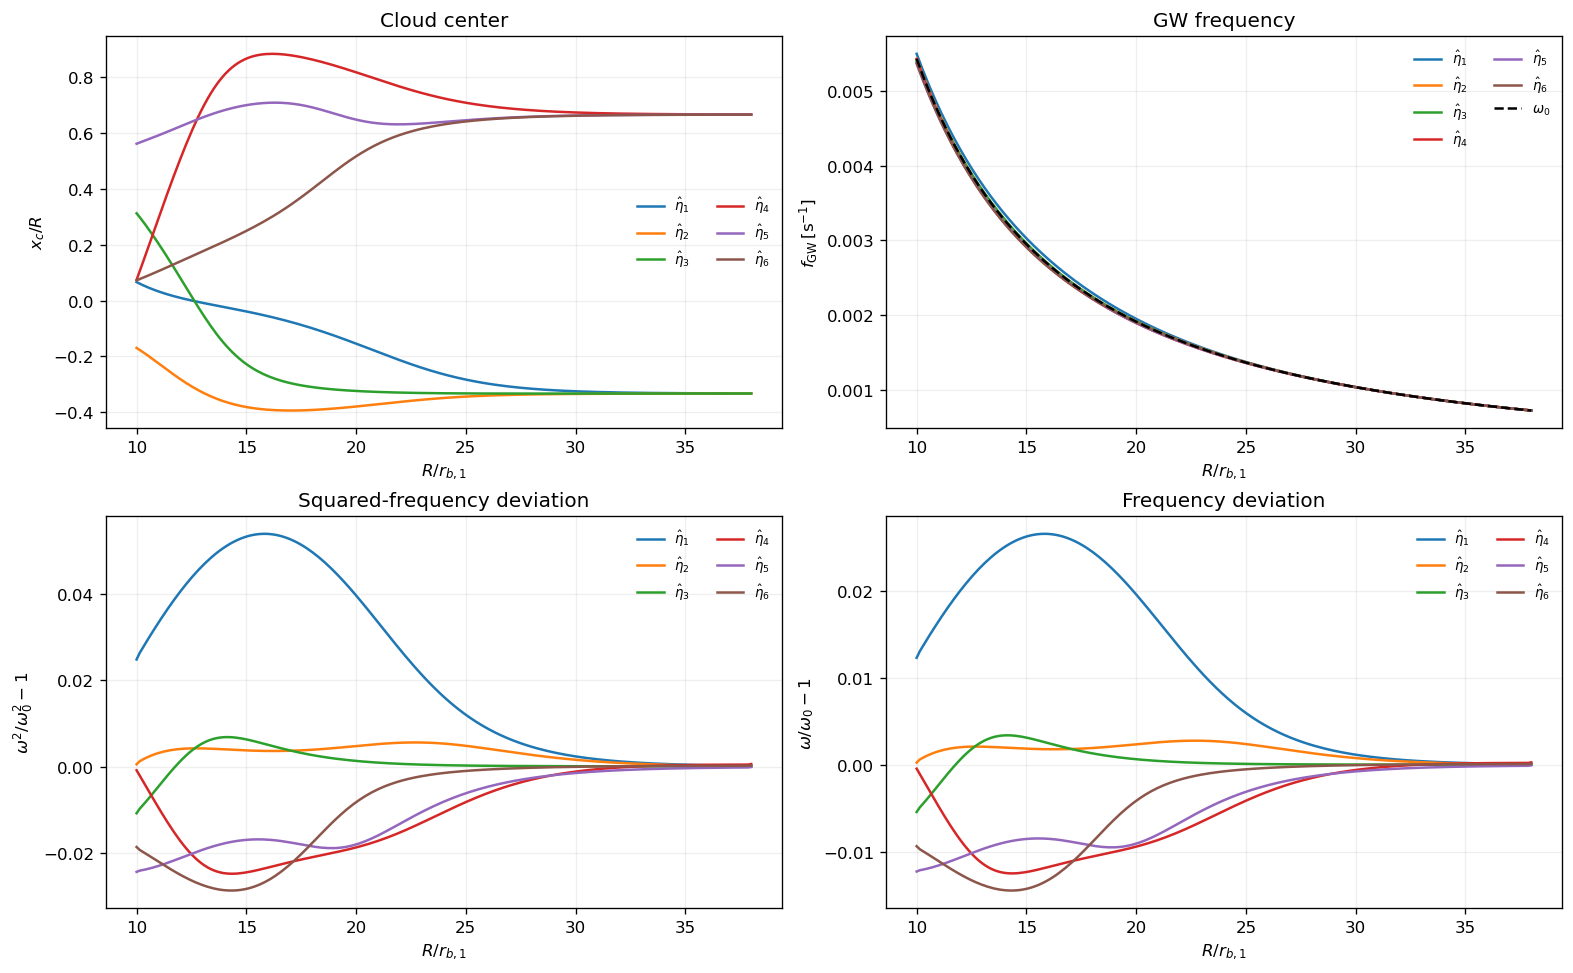

In [72]:
omega0_squared = isolated_binary_frequency_squared(model)
omega0 = np.sqrt(omega0_squared)
frequency_squared_deviation = model.gw_frequency_squared / omega0_squared[:, None] - 1.0
frequency_deviation = model.gw_frequency / omega0[:, None] - 1.0

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
plot_state_curves(axes[0, 0], model.tables.cloud_center / x[:, None], r'$x_c/R$')
plot_state_curves(
    axes[0, 1], model.gw_frequency / PLANCK_TIME_S,
    r'$f_{\rm GW}\,[\mathrm{s}^{-1}]$',
)
axes[0, 1].plot(x, omega0 / PLANCK_TIME_S, 'k--', label=r'$\omega_0$')
axes[0, 1].legend(fontsize=8, ncol=2)
plot_state_curves(
    axes[1, 0], frequency_squared_deviation,
    r'$\omega^2/\omega_0^2-1$',
)
plot_state_curves(
    axes[1, 1], frequency_deviation,
    r'$\omega/\omega_0-1$',
)
axes[0, 0].set_title('Cloud center')
axes[0, 1].set_title('GW frequency')
axes[1, 0].set_title('Squared-frequency deviation')
axes[1, 1].set_title('Frequency deviation')
plt.show()

## 4. 四极矩辐射功率

参考功率分别把前三个态的云质量并入主黑洞、后三个态的云质量并入次黑洞，与 Mathematica 的 `OriginalGRPower` 定义一致。

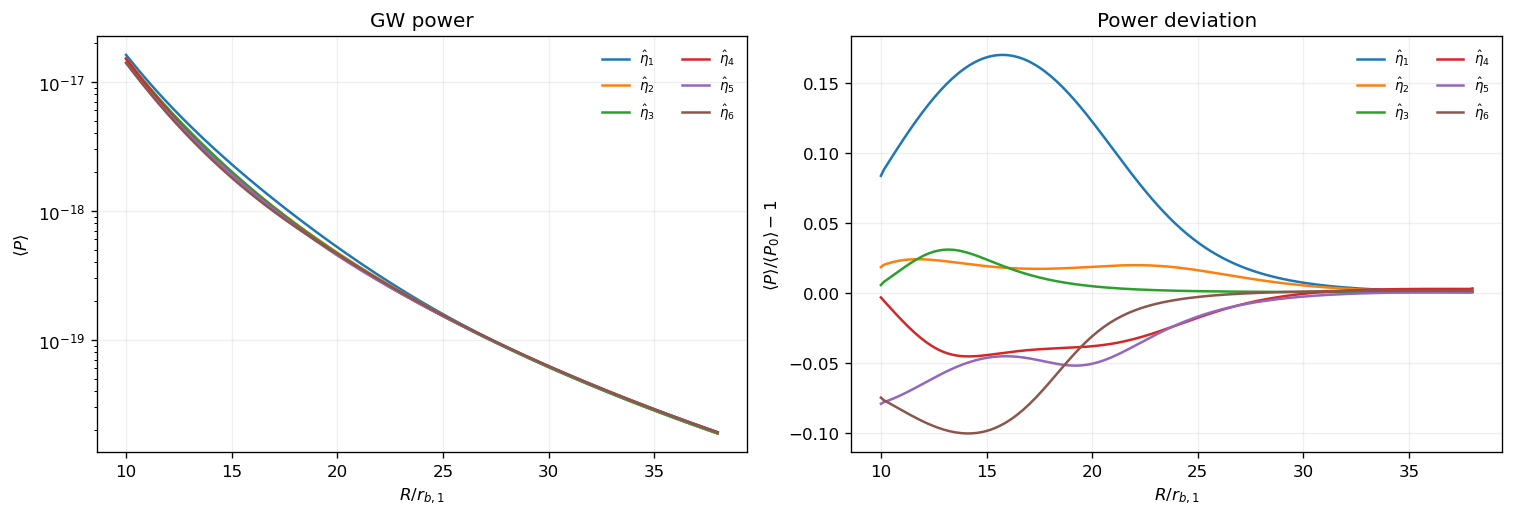

In [73]:
power0 = isolated_binary_power(model)
power_deviation = model.gr_power / power0 - 1.0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)
plot_state_curves(axes[0], model.gr_power, r'$\langle P\rangle$')
axes[0].set_yscale('log')
plot_state_curves(
    axes[1], power_deviation,
    r'$\langle P\rangle/\langle P_0\rangle-1$',
)
axes[0].set_title('GW power')
axes[1].set_title('Power deviation')
plt.show()

## 5. 实验室系中的云能量

第三幅图保留 Mathematica 中用于比较的解析参考曲线
`q(2+q) / (2 R^2 (1+q))`。对数图只显示正导数。

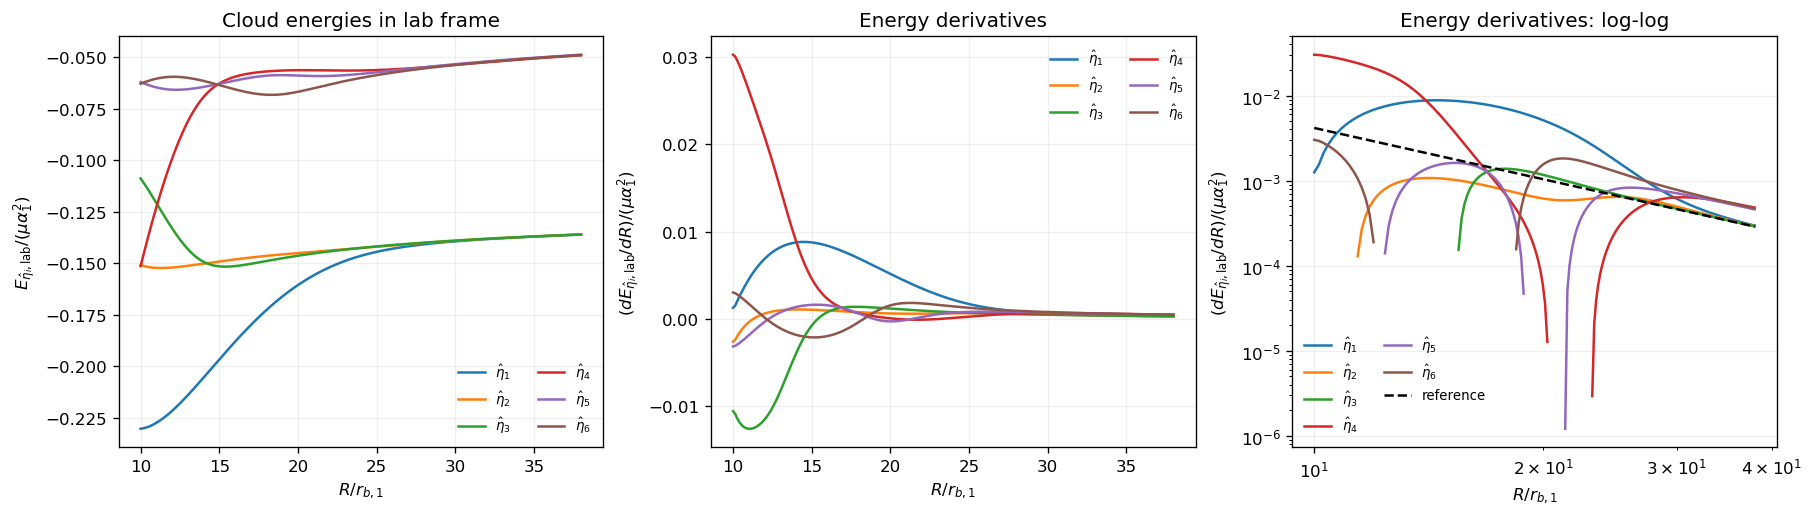

In [74]:
cloud_energy = model.cloud_energies_lab / scale
cloud_energy_derivative = model.cloud_energy_derivatives_lab / scale
derivative_reference = q * (2.0 + q) / (2.0 * x**2 * (1.0 + q))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_state_curves(
    axes[0], cloud_energy,
    r'$E_{\hat{\eta}_i,\rm lab}/(\mu\alpha_1^2)$',
)
plot_state_curves(
    axes[1], cloud_energy_derivative,
    r'$(dE_{\hat{\eta}_i,\rm lab}/dR)/(\mu\alpha_1^2)$',
)
positive_derivative = np.where(cloud_energy_derivative > 0.0, cloud_energy_derivative, np.nan)
plot_state_curves(
    axes[2], positive_derivative,
    r'$(dE_{\hat{\eta}_i,\rm lab}/dR)/(\mu\alpha_1^2)$',
    yscale='log',
)
axes[2].plot(x, derivative_reference, 'k--', label='reference')
axes[2].set_xscale('log')
axes[2].legend(fontsize=8, ncol=2)
axes[0].set_title('Cloud energies in lab frame')
axes[1].set_title('Energy derivatives')
axes[2].set_title('Energy derivatives: log-log')
plt.show()

## 6. 六个本征态的轨道演化与 chirp mass

对每个态求解能量平衡方程 `dE/dR * dR/dt = -P_GW`。若某组参数在网格内部出现 `dE/dR = 0`，`GMModel.evolve` 会在该稳定分支的末端停止，而不会跨越 ODE 奇点。

In [75]:
evolutions = [
    model.evolve(state=state, samples=evolution_samples)
    for state in range(6)
]
[(item.state, item.time_years[-1], item.separation[-1]) for item in evolutions]

[(0, np.float64(4573.02886147049), np.float64(10.140703517587939)),
 (1, np.float64(4720.34851132345), np.float64(10.140703517587944)),
 (2, np.float64(4775.908557522651), np.float64(10.140703517587927)),
 (3, np.float64(4856.44707752927), np.float64(10.140703517587959)),
 (4, np.float64(4858.129065190542), np.float64(10.14070351758798)),
 (5, np.float64(4825.83655486544), np.float64(10.140703517587912))]

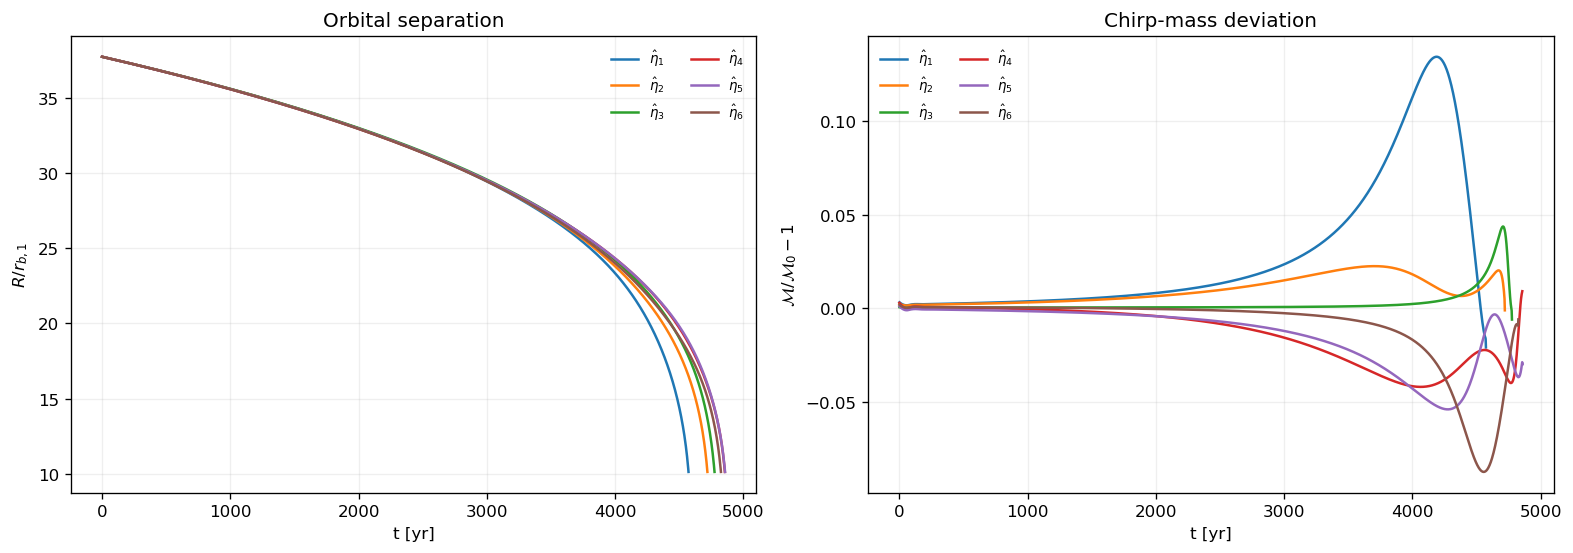

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for evolution, label in zip(evolutions, state_labels):
    axes[0].plot(evolution.time_years, evolution.separation, label=label)
    axes[1].plot(evolution.time_years, evolution.chirp_deviation, label=label)
axes[0].set(xlabel='t [yr]', ylabel=r'$R/r_{b,1}$', title='Orbital separation')
axes[1].set(
    xlabel='t [yr]',
    ylabel=r'$\mathcal{M}/\mathcal{M}_0-1$',
    title='Chirp-mass deviation',
)
for ax in axes:
    ax.legend(fontsize=8, ncol=2)
plt.show()

## 7. 加入超辐射增长宽度的非厄米本征系统

对应原 notebook 的 `GrowthWidth` 和 `ReducedHamiltonianWithGrowthWidth`。修正版视界角速度系数已经封装在 `gmlib.py`。

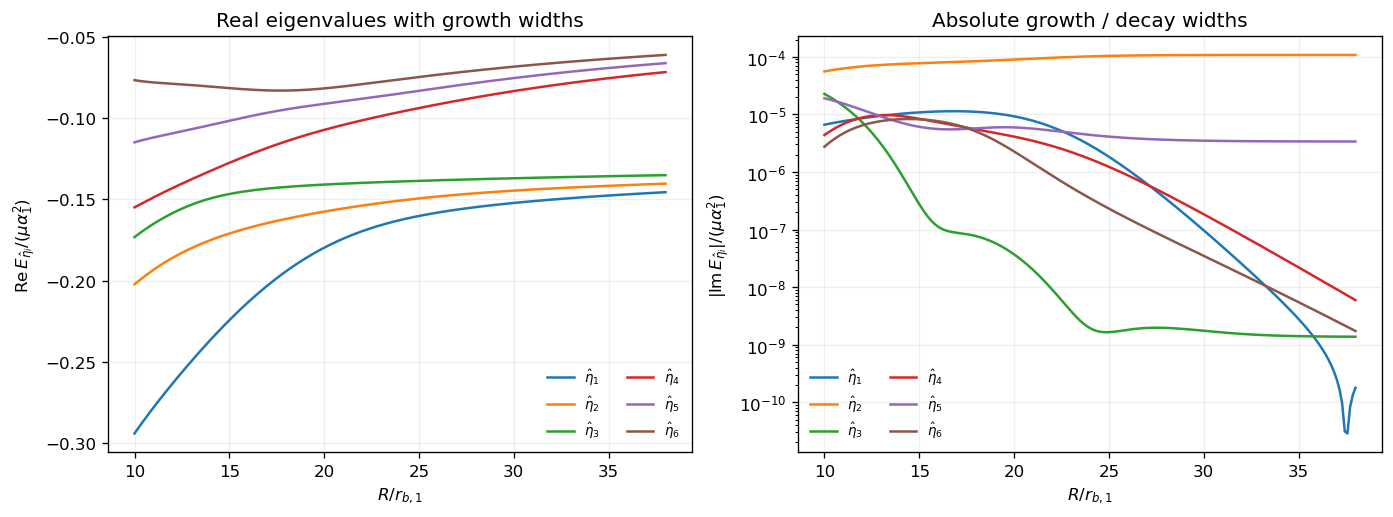

In [77]:
growth_axes = plot_growth_eigensystem(
    model, spin_primary=1.0, spin_secondary=1.0
)
growth_axes[0].set_title('Real eigenvalues with growth widths')
growth_axes[1].set_title('Absolute growth / decay widths')
plt.show()

## 8. LISA noise model 之前的信号特征应变

这里复现原 notebook 在分界前定义的 `dE/df`、GM 特征应变、孤立 BBH 特征应变和单频振幅。红移因子沿用原 Mathematica 表达式；本 notebook 在此结束，不包含后续 LISA 噪声曲线。

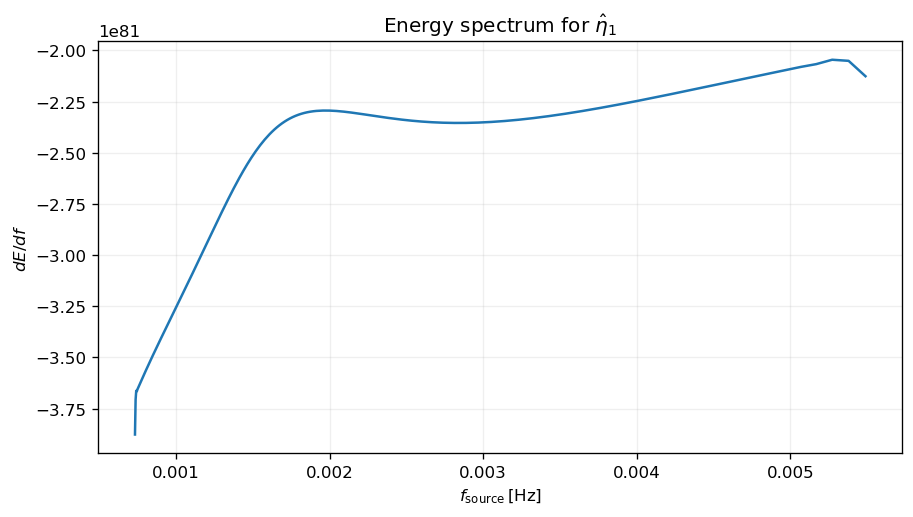

In [78]:
if strain_state not in range(6):
    raise ValueError('strain_state must be in range(6)')

frequency_planck = model.gw_frequency[:, strain_state]
system_energy = model.system_energies_lab[:, strain_state]
energy_spline = CubicSpline(x, system_energy)
frequency_spline = CubicSpline(x, frequency_planck)
denergy_dfrequency = energy_spline.derivative()(x) / frequency_spline.derivative()(x)

# Build dE/df as a single-valued interpolation on the sampled frequency branch.
order = np.argsort(frequency_planck)
sorted_frequency, unique_indices = np.unique(frequency_planck[order], return_index=True)
sorted_denergy_dfrequency = denergy_dfrequency[order][unique_indices]
denergy_dfrequency_spline = CubicSpline(sorted_frequency, sorted_denergy_dfrequency)

source_frequency_hz = sorted_frequency / PLANCK_TIME_S
fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax.plot(source_frequency_hz, sorted_denergy_dfrequency)
ax.set(xlabel=r'$f_{\rm source}\,[\mathrm{Hz}]$', ylabel=r'$dE/df$')
ax.set_title(rf'Energy spectrum for {state_labels[strain_state]}')
plt.show()

detector_frequency_hz = np.linspace(
    source_frequency_hz[0] / (1.0 + redshift),
    source_frequency_hz[-1] / (1.0 + redshift),
    800,
)
source_frequency_planck = (
    (1.0 + redshift) * detector_frequency_hz * PLANCK_TIME_S
)
distance = luminosity_distance_planck(redshift)
minus_denergy_dfrequency = -denergy_dfrequency_spline(source_frequency_planck)
if np.any(minus_denergy_dfrequency <= 0.0):
    raise FloatingPointError('-dE/df must remain positive on the selected branch')

hc_gm = np.sqrt(
    2.0 * (1.0 + redshift) ** 2
    / (np.pi**2 * distance**2)
    * minus_denergy_dfrequency
)
chirp_mass = (
    (parameters.primary_mass * parameters.secondary_mass) ** (3.0 / 5.0)
    / (parameters.primary_mass + parameters.secondary_mass) ** (1.0 / 5.0)
)
hc_bbh = np.sqrt(
    2.0 / (np.pi**2 * distance**2)
    * np.pi ** (2.0 / 3.0) / 3.0
    * ((1.0 + redshift) * chirp_mass) ** (5.0 / 3.0)
    * (detector_frequency_hz * PLANCK_TIME_S) ** (-1.0 / 3.0)
)
monochromatic_amplitude = (
    4.0 / distance
    * ((1.0 + redshift) * chirp_mass) ** (5.0 / 3.0)
    * (np.pi * PLANCK_TIME_S * detector_frequency_hz) ** (2.0 / 3.0)
)

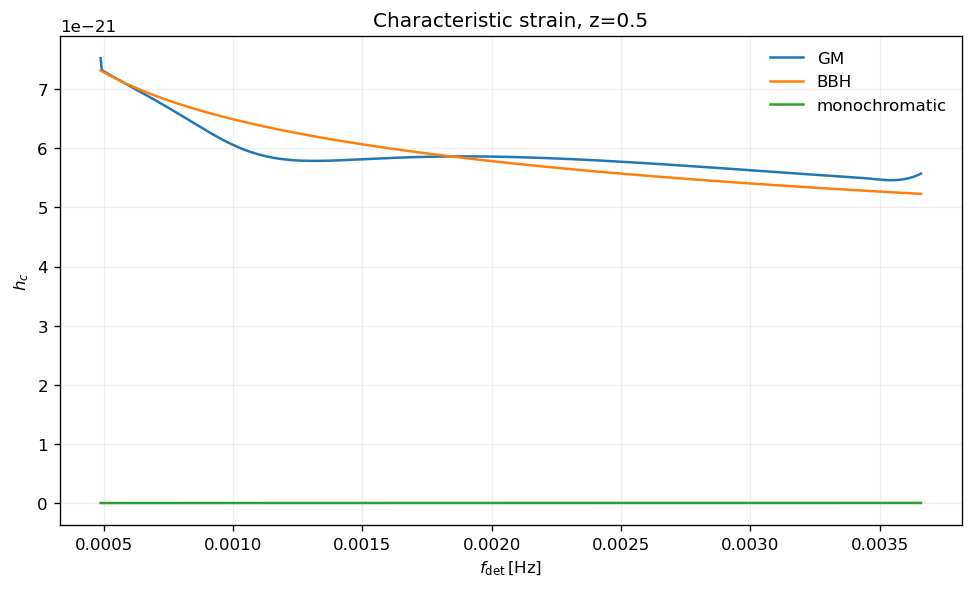

In [79]:
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
ax.plot(detector_frequency_hz, hc_gm, label='GM')
ax.plot(detector_frequency_hz, hc_bbh, label='BBH')
ax.plot(detector_frequency_hz, monochromatic_amplitude, label='monochromatic')
ax.set(xlabel=r'$f_{\rm det}\,[\mathrm{Hz}]$', ylabel=r'$h_c$')
ax.set_title(f'Characteristic strain, z={redshift:g}')
ax.legend()
plt.show()

## 结束位置

以上即 `GMMainPlot_v2.0.nb` 中 **LISA noise model** 标题之前的可计算内容。Mathematica 文件中误存为 Input 的压缩静态图没有复制；其对应的物理曲线已由上面的 Python cell 重新生成。